# Часть 1. Анализ A/B-теста

## Загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
df = pd.read_csv('data_ab.csv')

In [ ]:
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1


In [ ]:
df.shape

(294478, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [ ]:
df.isna().sum()

,0
user_id,0
timestamp,0
group,0
landing_page,0
converted,0


В нашем наборе данных есть 5 колонок:
- user_id: уникальный номер пользователя;
- timestamp: время, когда пользователь посетил страницу;
- group: к какой группе относится пользователь (контрольная или тестовая);
- landing_page: какую версию страницы видел пользователь;
- converted: показатель конверсии (1, если пользователь совершил целевое действие, 0 – если нет).
Радует, что пропусков в данных нет! Для анализа будем смотреть на долю пользователей, которые совершили конверсию (converted = 1).

## Проверяем, кто что видел
По условиям нашего A/B-теста, пользователи из контрольной группы (control) должны были видеть старую версию страницы (old_page), а пользователи из тестовой группы (treatment) — новую (new_page). Давайте убедимся, что так и есть.

Прежде чем начать удалять данные, давайте посмотрим, сколько у нас повторяющихся `user_id`. Это важно, чтобы потом понимать, сколько уникальных пользователей у нас осталось.

In [ ]:
df['user_id'].duplicated().sum()

np.int64(3894)

In [ ]:
df['group'].value_counts()

,count
group,
treatment,147276
control,147202


In [ ]:
df['landing_page'].value_counts()

,count
landing_page,
old_page,147239
new_page,147239


In [ ]:
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


Обнаружились записи, где группа пользователя и показанная ему страница не совпадают. Например, кто-то из контрольной группы увидел новую страницу. Такие данные некорректны, и лучше их удалить, чтобы не искажать результаты теста.

Прежде чем что-то удалять, давайте поближе рассмотрим эти повторяющиеся user_id.

In [ ]:
dup = df[df['user_id'].duplicated(keep=False)]

In [ ]:
dup.sort_values('user_id').head(20)

,user_id,timestamp,group,landing_page,converted
213114,630052,2025-01-07 12:25:54.089486,treatment,old_page,1
230259,630052,2025-01-17 01:16:05.208766,treatment,new_page,0
251762,630126,2025-01-19 17:16:00.280440,treatment,new_page,0
22513,630126,2025-01-14 13:35:54.778695,treatment,old_page,0
11792,630137,2025-01-22 14:59:22.051308,control,new_page,0
183371,630137,2025-01-20 02:08:49.893878,control,old_page,0
255753,630320,2025-01-12 05:27:37.181803,treatment,old_page,0
207211,630320,2025-01-07 18:02:43.626318,control,old_page,0
110634,630471,2025-01-23 01:42:51.501851,control,old_page,0
96929,630471,2025-01-07 02:14:17.405726,control,new_page,0


In [ ]:
same = dup.groupby('user_id').nunique()
same.head()

,timestamp,group,landing_page,converted
user_id,,,,
630052,2,1,2,2
630126,2,1,2,1
630137,2,1,2,1
630320,2,2,1,1
630471,2,1,2,1


In [ ]:
bad_users = same[(same > 1).any(axis=1)]
bad_users.shape

(3894, 4)

In [ ]:
df[df['user_id'].isin(bad_users.index)].sort_values('user_id').head(20)

,user_id,timestamp,group,landing_page,converted
213114,630052,2025-01-07 12:25:54.089486,treatment,old_page,1
230259,630052,2025-01-17 01:16:05.208766,treatment,new_page,0
251762,630126,2025-01-19 17:16:00.280440,treatment,new_page,0
22513,630126,2025-01-14 13:35:54.778695,treatment,old_page,0
11792,630137,2025-01-22 14:59:22.051308,control,new_page,0
183371,630137,2025-01-20 02:08:49.893878,control,old_page,0
255753,630320,2025-01-12 05:27:37.181803,treatment,old_page,0
207211,630320,2025-01-07 18:02:43.626318,control,old_page,0
110634,630471,2025-01-23 01:42:51.501851,control,old_page,0
96929,630471,2025-01-07 02:14:17.405726,control,new_page,0


Интересно, что у пользователей-дубликатов часто меняется либо группа, либо версия страницы. Это еще раз подтверждает, что сначала нужно разобраться с некорректными сочетаниями группы и страницы.

In [ ]:
wrong = (
    ((df['group'] == 'control') & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
)

wrong.sum()

np.int64(3893)

In [ ]:
df = df[~wrong].copy()

In [ ]:
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145311,0


Отлично, теперь у нас группы и страницы распределены правильно. Давайте снова проверим, остались ли у нас дубликаты пользователей.

In [ ]:
df['user_id'].duplicated().sum()

np.int64(1)

Похоже, остался всего один повторяющийся пользователь. Давайте посмотрим на его записи вручную.

In [ ]:
dup = df[df['user_id'].duplicated(keep=False)]

In [ ]:
dup.sort_values('user_id')

,user_id,timestamp,group,landing_page,converted
1899,773192,2025-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2025-01-14 02:55:59.590927,treatment,new_page,0


У этого пользователя-дубликата отличаются только даты посещений. Группа, страница и результат конверсии у него одинаковые. Значит, можно смело оставить только одну запись, чтобы избежать задвоения.

In [ ]:
df = df.drop_duplicates('user_id').copy()

In [ ]:
df.shape

(290584, 5)

## Подготовка времени

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
df['date'] = df['timestamp'].dt.date

In [ ]:
df['timestamp'].min(), df['timestamp'].max()

(Timestamp('2025-01-02 13:42:05.378582'),
 Timestamp('2025-01-24 13:41:54.460509'))

Тест проводился примерно с 2 по 24 января 2025 года.

## Размеры групп

In [ ]:
df['group'].value_counts()

,count
group,
treatment,145310
control,145274


In [ ]:
df['group'].value_counts(normalize=True)

,proportion
group,
treatment,0.500062
control,0.499938


Мы видим, что группы почти одинаковы по размеру, что очень хорошо для чистоты эксперимента. Сильного перекоса нет, так что можно двигаться дальше.

## Конверсия по группам

In [ ]:
df.groupby('group')['converted'].agg(['count', 'sum', 'mean'])

,count,sum,mean
group,,,
control,145274,17489,0.120386
treatment,145310,17264,0.118808


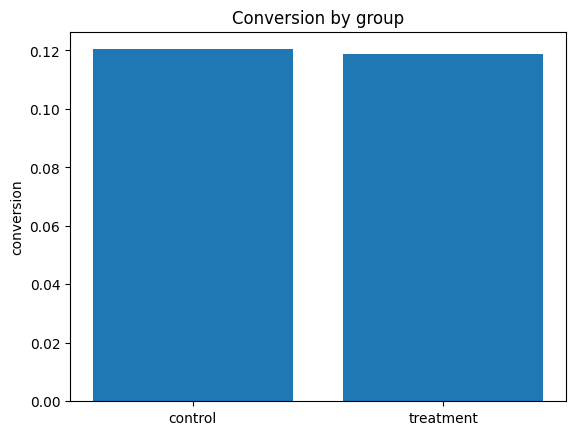

In [ ]:
conv = df.groupby('group')['converted'].mean()

plt.bar(conv.index, conv.values)
plt.ylabel('conversion')
plt.title('Conversion by group')
plt.show()

Конверсия в группах отличается совсем незначительно. Если судить по этим предварительным данным, новая страница пока не показывает явного преимущества.

## Динамика пользователей по дням

In [ ]:
daily_users = df.groupby(['date', 'group'])['user_id'].count().unstack()

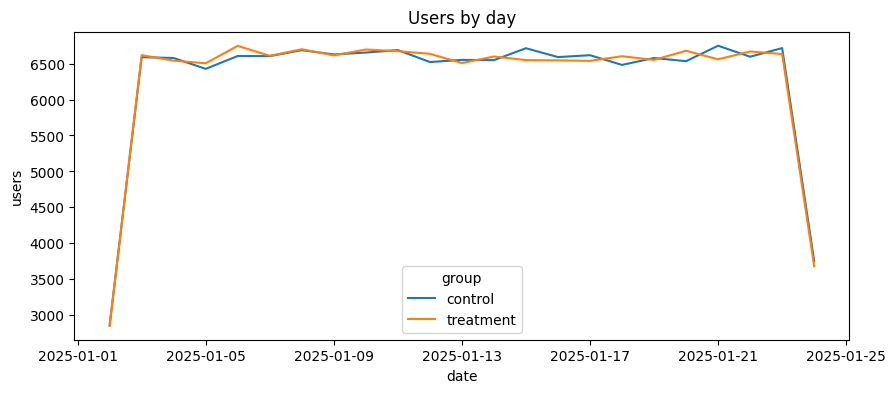

In [ ]:
daily_users.plot(figsize=(10, 4))
plt.ylabel('users')
plt.title('Users by day')
plt.show()

Динамика количества пользователей в обеих группах по дням выглядит очень похоже.

## Конверсия по дням

In [ ]:
daily_conv = df.groupby(['date', 'group'])['converted'].mean().unstack()

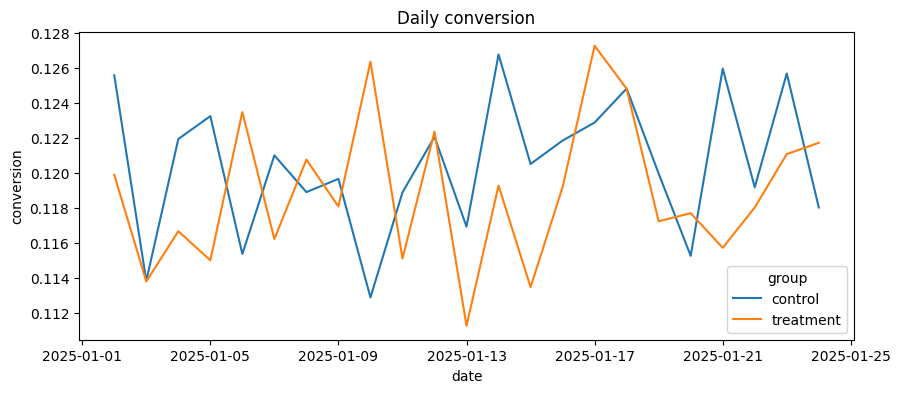

In [ ]:
daily_conv.plot(figsize=(10, 4))
plt.ylabel('conversion')
plt.title('Daily conversion')
plt.show()

Если посмотреть на конверсию по дням, то и здесь мы не видим четкого и стабильного преимущества новой страницы.

## Гипотезы

Настало время проверить наши гипотезы о том, равны ли конверсии для старой и новой страницы.
- Нулевая гипотеза (H0): Конверсия у старой и новой страницы одинаковая.
- Альтернативная гипотеза (H1): Конверсии все-таки отличаются.
Поскольку мы работаем с бинарной метрикой (конверсия) и у нас большие, независимые выборки, для проверки будем использовать z-тест для двух долей.

In [ ]:
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

In [ ]:
success = [
    control['converted'].sum(),
    treatment['converted'].sum()
]

nobs = [
    control.shape[0],
    treatment.shape[0]
]

success, nobs

([np.int64(17489), np.int64(17264)], [145274, 145310])

In [ ]:
stat, pval = proportions_ztest(success, nobs)
stat, pval

(np.float64(1.3109241984234394), np.float64(0.18988337448195103))

In [ ]:
alpha = 0.05

if pval < alpha:
    print('Отвергаем H0')
else:
    print('Нет оснований отвергать H0')

Нет оснований отвергать H0


Мы получили p-value, который больше 0.05. Это значит, что у нас нет достаточных оснований, чтобы отвергнуть нулевую гипотезу. Другими словами, мы не нашли статистически значимых различий в конверсии между группами.

## Доверительный интервал для разницы

In [ ]:
p_old = control['converted'].mean()
p_new = treatment['converted'].mean()

diff = p_new - p_old

diff

np.float64(-0.0015782389853555567)

In [ ]:
se = np.sqrt(
    p_old * (1 - p_old) / control.shape[0] +
    p_new * (1 - p_new) / treatment.shape[0]
)

left = diff - 1.96 * se
right = diff + 1.96 * se

left, right

(np.float64(-0.003937903604443846), np.float64(0.0007814256337327326))

Так как доверительный интервал включает в себя 0, это подтверждает выводы z-теста: статистически значимых различий нет.

## Bootstrap

В качестве дополнительной проверки, давайте оценим разницу конверсий, используя метод бутстрэпа (bootstrap).

In [ ]:
control_values = control['converted'].values
treatment_values = treatment['converted'].values

In [ ]:
boot = []

for _ in range(3000):
    c = np.random.choice(control_values, size=len(control_values), replace=True)
    t = np.random.choice(treatment_values, size=len(treatment_values), replace=True)
    boot.append(t.mean() - c.mean())

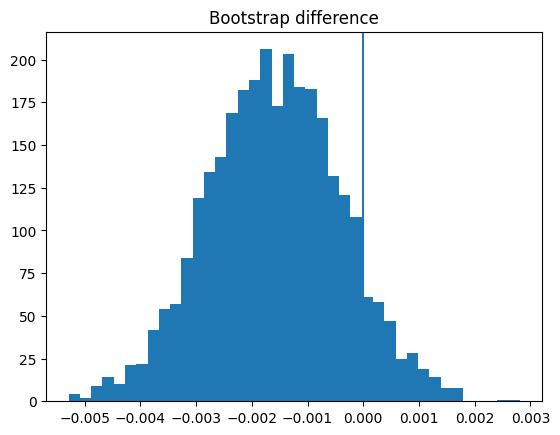

In [ ]:
plt.hist(boot, bins=40)
plt.axvline(0)
plt.title('Bootstrap difference')
plt.show()

In [ ]:
np.percentile(boot, [2.5, 97.5])

array([-0.00393249,  0.00080302])

Бутстрэп-интервал также включает в себя 0. Это значит, что и этот метод не показал значимого улучшения конверсии для новой страницы.

## Итоговый вывод

В этом разделе мы проанализировали результаты A/B-теста для новой версии лендинга.
Сперва мы тщательно подготовили данные: удалили записи, где группа и показанная страница не совпадали, и избавились от оставшихся дубликатов пользователей.
После очистки данных, обе группы оказались почти идентичными по размеру. При этом конверсия в контрольной группе была чуть выше, но разница между ними оказалась совсем незначительной.
Z-тест показал p-value больше 0.05, и это подтвердили также доверительный интервал и метод бутстрэпа: статистически значимой разницы между старой и новой версией страницы нет.
Таким образом, мы не можем утверждать, что новая версия лендинга привела к улучшению конверсии.